<a href="https://colab.research.google.com/github/poonamkhot123/Machine-Learning-Practice-Hub/blob/main/Day_30_Function_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [20]:
df = pd.read_csv("/content/tested.csv",usecols=['Age','Fare','Survived'])

In [21]:
df

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875
...,...,...,...
413,0,NaN,8.0500
414,1,39.0,108.9000
415,0,38.5,7.2500
416,0,NaN,8.0500


In [22]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    int64  
 1   Age       332 non-null    float64
 2   Fare      417 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 9.9 KB


In [24]:
df.isnull().sum()

,0
Survived,0
Age,86
Fare,1


In [25]:
df["Age"].fillna(df["Age"].mean(),inplace=True)

/tmp/ipykernel_3863/2595122914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)


In [26]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [29]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,1


In [30]:
x = df.iloc[:,1:3]
y = df.iloc[:,0]

In [31]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

/tmp/ipykernel_3863/2079125179.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["Age"])


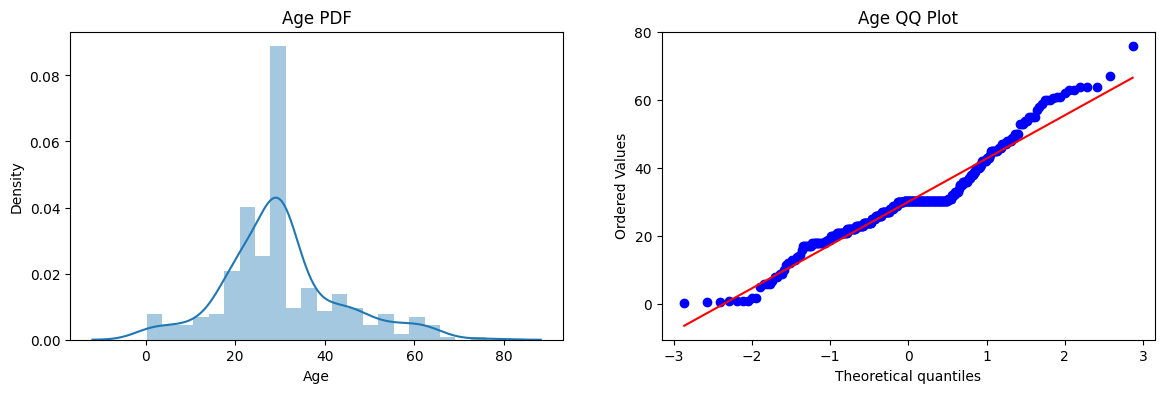

In [32]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train["Age"])
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(x_train["Age"],dist='norm',plot=plt)
plt.title("Age QQ Plot")
plt.show()

In [34]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [39]:
x_train["Fare"].fillna(x_train["Fare"].mean(),inplace=True)
x_test["Fare"].fillna(x_test["Fare"].mean(),inplace=True)

clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred = clf.predict(x_test)
y_pred1 = clf2.predict(x_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6071428571428571
Accuracy DT 0.5833333333333334


/tmp/ipykernel_3863/4267765242.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train["Fare"].fillna(x_train["Fare"].mean(),inplace=True)
/tmp/ipykernel_3863/4267765242.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [42]:
trf = FunctionTransformer(func=np.log1p)

In [43]:
x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.transform(x_test)

In [44]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred = clf.predict(x_test)
y_pred1 =clf2.predict(x_test)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.5714285714285714
Accuracy DT 0.6071428571428571


In [48]:
x_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,x_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,x_transformed,y,scoring='accuracy',cv=10)))

LR nan
DT 0.5980836236933798


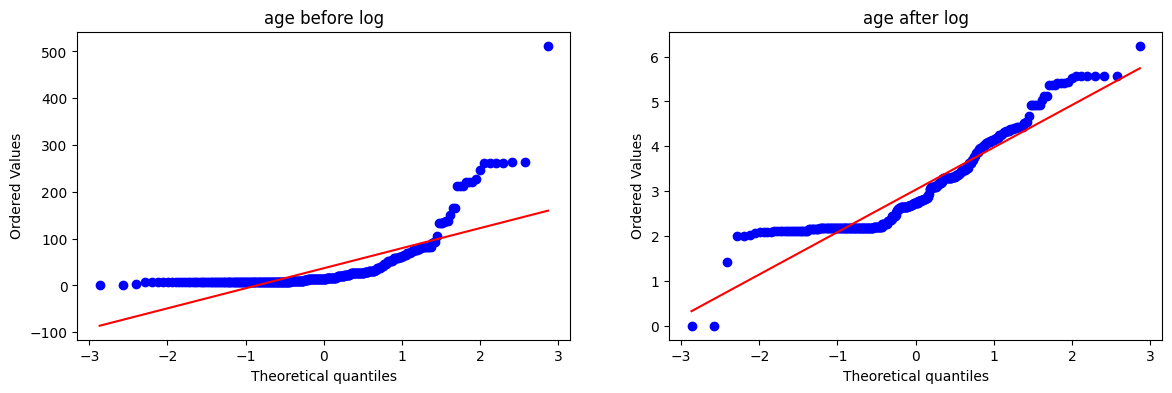

In [49]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title("age before log")

plt.subplot(122)
stats.probplot(x_train_transformed['Fare'],dist='norm',plot=plt)
plt.title("age after log")


plt.show()

In [50]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

x_train_trnasformed2 = trf2.fit_transform(x_train)
x_test_transformed2 = trf2.transform(x_test)

In [51]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train_trnasformed2,y_train)
clf2.fit(x_train_trnasformed2,y_train)

y_pred = clf.predict(x_test_transformed2)
y_pred1 = clf2.predict(x_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6190476190476191
Accuracy DT 0.5714285714285714


In [52]:
x_transformed2 = trf2.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,x_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,x_transformed2,y,scoring='accuracy',cv=10)))

LR nan
DT 0.5909407665505226


In [56]:
def apply_transform(transform):
  x = df.iloc[:,1:3]
  y = df.iloc[:,0]

  trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
  x_trans = trf.fit_transform(x)

  clf = LogisticRegression()

  print("Accuracy",np.mean(cross_val_score(clf,x_trans,y,scoring='accuracy',cv=10)))

  plt.figure(figure=(14,4))

  plt.subplot(121)
  stats.probplot(x['Fare'],dist='norm',plot=plt)
  plt.title("Fare Before Transform")

  plt.subplot(122)
  stats.probplot(x_trans[:,0],dist='norm',plot=plt)
  plt.title("Fare After Transform")


  plt.show()


